In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator, FixedFormatter
import numpy as np

%matplotlib inline

mpl.rcParams.update({
    'font.size': 10, 'axes.labelsize': 10, 'xtick.labelsize': 9,
    'ytick.labelsize': 9, 'legend.fontsize': 8, 'lines.linewidth': 1.5,
    'lines.markersize': 5, 'figure.dpi': 150, 'axes.grid': True,
    'grid.alpha': 0.3, 'pdf.fonttype': 42,
})

# --- config ---
PARQUET  = "diffusion.parquet"
HEADS    = [2, 4, 8]
BATCHES  = [64, 128, 256, 512, 1024]
LOGLRS   = [-9.0, -10.0, -11.0, -12.0, -13.0]
MAX_SAMPLES = 40 * 1281167   # 40 epochs × ImageNet size
CBS_THRESHOLD = 1.0 / 1.2

LOSS_TARGETS = {
    2: [1.0, 0.5, 0.2, 0.165],
    4: [1.0, 0.4, 0.2, 0.18, 0.17, 0.165, 0.16, 0.158],
    8: [1.0, 0.4, 0.2, 0.18, 0.17, 0.165, 0.16, 0.158, 0.154, 0.152, 0.15],
}
GNS_CONFIG = {h: {'bs': 256, 'loglr': -11.0} for h in HEADS}

COLORS  = {2: '#4477AA', 4: '#EE6677', 8: '#228833'}
MARKERS = {2: 'o', 4: 's', 8: '^'}
LABELS  = {2: 'Width 144', 4: 'Width 288', 8: 'Width 576'}
XMIN, XMAX = 0.145, 0.18

In [2]:
df_all = pd.read_parquet(PARQUET)
df_all = df_all[df_all['samples_seen'] <= MAX_SAMPLES]

def get_slice(heads, bs, loglr):
    return (
        df_all[(df_all['heads'] == heads) & (df_all['batch_size'] == bs) & (df_all['log_lr'] == loglr)]
        .sort_values('samples_seen').reset_index(drop=True)
    )

def smooth_cbs(df, bs):
    s = df[['samples_seen', 'train/loss']].copy()
    s['train/loss'] = pd.to_numeric(s['train/loss'], errors='coerce')
    s = s.dropna().pipe(lambda d: d[np.isfinite(d['train/loss'])])
    span = max(5, int(1024 / np.sqrt(bs)))
    s['loss_s'] = s['train/loss'].ewm(span=span, adjust=False).mean()
    return s

def smooth_gns(df):
    s = df[['samples_seen', 'train/loss', 'gns']].copy()
    s['loss_s'] = s['train/loss'].rolling(32, center=True).mean()
    s['gns_s']  = s['gns'].rolling(32, center=True).mean()
    return s.dropna(subset=['loss_s', 'gns_s'])

def find_cbs(target_loss, heads):
    results = []
    for bs in BATCHES:
        for loglr in LOGLRS:
            df = smooth_cbs(get_slice(heads, bs, loglr), bs)
            if df.empty:
                continue
            hit = df['loss_s'] <= target_loss
            if not hit.any():
                continue
            idx = hit.idxmax()
            if (len(df) - df.index.get_loc(idx)) / len(df) < 0.2:
                continue
            results.append({'bs': bs, 'loglr': loglr, 'n': df.loc[idx, 'samples_seen']})

    if not results:
        return np.nan

    best = (pd.DataFrame(results)
            .sort_values('n').groupby('bs', sort=False).first().reset_index()
            .sort_values('bs'))
    best['speedup'] = best['n'].iloc[0] / best['n']

    for i in range(1, len(best)):
        if best['speedup'].iloc[i] < CBS_THRESHOLD:
            b1, b2 = best['bs'].iloc[i-1], best['bs'].iloc[i]
            s1, s2 = best['speedup'].iloc[i-1], best['speedup'].iloc[i]
            t = (CBS_THRESHOLD - s1) / (s2 - s1)
            return np.exp(np.log(b1) + t * (np.log(b2) - np.log(b1)))

    return best['bs'].iloc[-1]

In [3]:
cbs_results = {
    h: [find_cbs(loss, h) for loss in LOSS_TARGETS[h]]
    for h in HEADS
}

gns_results = {
    h: smooth_gns(get_slice(h, GNS_CONFIG[h]['bs'], GNS_CONFIG[h]['loglr']))
    for h in HEADS
}

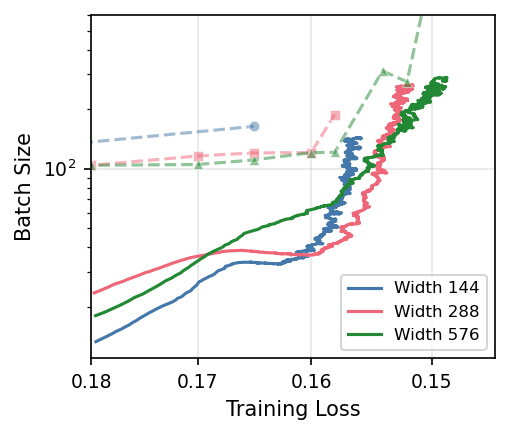

In [4]:
fig, ax = plt.subplots(figsize=(3.5, 3.0))

for h in HEADS:
    # GNS — solid line
    gns = gns_results[h]
    gns = gns[(gns['loss_s'] >= XMIN) & (gns['loss_s'] <= XMAX)]
    ax.plot(gns['loss_s'], gns['gns_s'], color=COLORS[h], label=LABELS[h])

    # CBS — dashed line
    pairs = [(l, c) for l, c in zip(LOSS_TARGETS[h], cbs_results[h]) if not np.isnan(c)]
    if pairs:
        lx, cy = zip(*pairs)
        ax.plot(lx, cy, marker=MARKERS[h], color=COLORS[h],
                linestyle='--', alpha=0.5, markeredgecolor='white', markeredgewidth=0.5)

ax.set_xlabel('Training Loss')
ax.set_ylabel('Batch Size')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(XMIN, XMAX); ax.invert_xaxis()
ax.set_ylim(11, 600)
ax.xaxis.set_major_locator(FixedLocator([0.15, 0.16, 0.17, 0.18]))
ax.xaxis.set_major_formatter(FixedFormatter(['0.15', '0.16', '0.17', '0.18']))
ax.xaxis.set_minor_locator(FixedLocator([]))
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

In [5]:
for fmt in ['pdf', 'png']:
    fig.savefig(f'cbs_gns_diffusion.{fmt}', format=fmt, pad_inches=0.02)